# 04: Regional Consumer Analysis

## Objective

Compare all eight Project 007 regions directly: market size, growth, spending power, and structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../src/visualisation')
regional = pd.read_csv('../outputs/tables/regional_profiles.csv')
regional[['Project_007_Region','n_countries','global_consumption_share_pct','median_consumption_per_capita','median_cagr_real_pct']]

,Project_007_Region,n_countries,global_consumption_share_pct,median_consumption_per_capita,median_cagr_real_pct
0,North America,4,33.923969,35995.229621,1.580324
1,Europe,46,23.896522,10844.668460,2.390098
2,East Asia,6,18.250738,18604.435737,2.032676
3,South & Southeast Asia,18,8.001159,2106.092145,4.608473
4,Latin America,25,7.459058,5191.986850,2.626659
5,Middle East,18,3.896152,7313.541886,2.800215
6,Africa,50,2.800281,995.663461,3.728403
7,Oceania,15,1.772120,7842.010307,2.384107


In [2]:
# House chart style v2: consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
import matplotlib.pyplot as plt

ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Global consumer spending by region

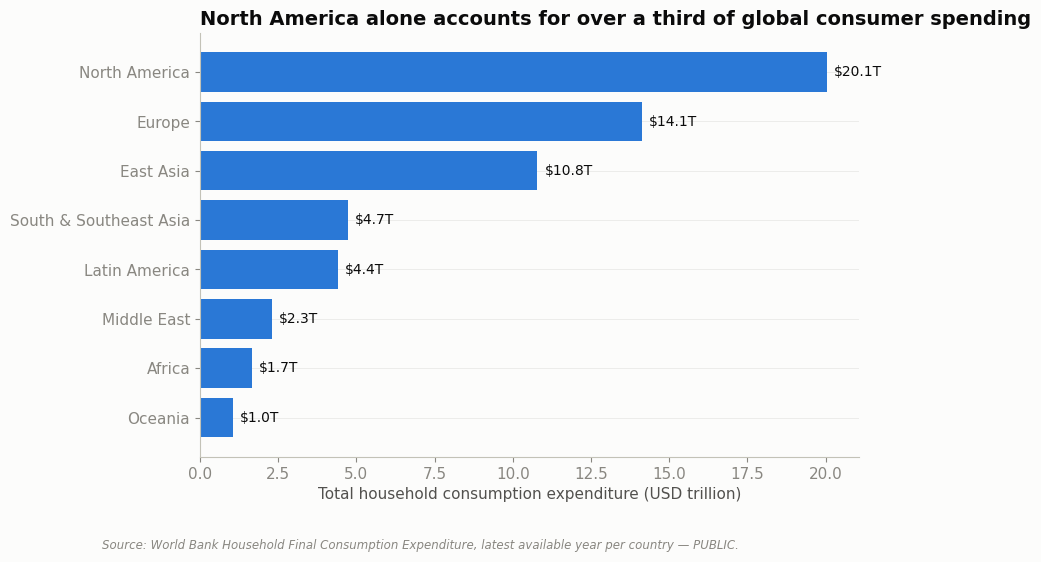

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
r = regional.sort_values('total_consumption_usd')
bars = ax.barh(r['Project_007_Region'], r['total_consumption_usd']/1e12, color=ACCENT_1)
for b in bars:
    ax.annotate(f'${b.get_width():.1f}T', xy=(b.get_width(), b.get_y()+b.get_height()/2), xytext=(5,0), textcoords='offset points', va='center', fontsize=10)
ax.set_title('North America alone accounts for over a third of global consumer spending', loc='left')
ax.set_xlabel('Total household consumption expenditure (USD trillion)')
add_source(ax.figure, 'Source: World Bank Household Final Consumption Expenditure, latest available year per country \u2014 PUBLIC.')
plt.show()

## Regional growth trajectories, indexed to 2013

In [4]:
master = pd.read_csv('../data/processed/master_consumer_spending.csv')
trend = master.dropna(subset=['household_consumption_expenditure_constant_2015_usd'])
rt = trend.groupby(['Project_007_Region','Year'])['household_consumption_expenditure_constant_2015_usd'].sum().reset_index()
pivot = rt.pivot(index='Year', columns='Project_007_Region', values='household_consumption_expenditure_constant_2015_usd')
indexed = pivot / pivot.loc[2013] * 100
indexed.round(1).tail()

Project_007_Region,Africa,East Asia,Europe,Latin America,Middle East,North America,Oceania,South & Southeast Asia
Year,,,,,,,,
2019,120.7,134.2,111.6,108.1,115.6,117.2,117.0,143.4
2020,121.5,129.3,103.1,100.2,113.1,114.0,113.7,137.6
2021,128.2,141.2,108.8,108.1,120.9,123.8,115.4,147.4
2022,132.8,143.8,114.0,113.7,133.6,127.8,120.1,158.1
2023,137.6,153.3,115.1,116.5,143.0,131.0,126.5,165.7


## Key Regional Findings

1. **North America's dominance is a market-size story, not a growth story.** It holds ~34% of global consumer spending but has one of the slower real growth rates (median CAGR ~1.6%), a large, mature base.
2. **South & Southeast Asia and Africa are the fastest-growing regions** (median CAGR 4.6% and 3.7% respectively), but from a much smaller combined base (~11% of global spending together).
3. **Europe holds the second-largest share (~24%) with moderate growth (~2.4%)**, a large, moderately mature market, not a high-growth one.

## Confidence & Caveats

- Regional totals sum each country's *latest available* year, which for a small number of countries (11 of 182) is earlier than 2023. See Notebook 02. This has a negligible effect on regional totals since those countries are small markets.
- "Region" here is the Project 007 mapping (`REGION_MAPPING.csv`), not an official statistical region. See Notebook 02 for the full, documented mapping methodology.